# 1. Image moving

In [85]:
from pathlib import Path
from pathlib import PurePath
import numpy as np
from PIL import Image
import random
import shutil

In [86]:
image_datatypes = ['.png', '.jpg', 'jpeg']                                                                              # important
random_image = False                                                               


### 1.1. Images are moved from the YOUR data folder to their designated folders for preprocessing.

In [87]:
train_images_dir = Path('./YOUR_data/train_images')
train_masks_dir  = Path('./YOUR_data/train_masks')
test_images_dir  = Path('./YOUR_data/test_images')
test_masks_dir   = Path('./YOUR_data/test_masks')

destination_root = Path('./image_preprocessing/data')
train_data  = destination_root / 'train'
test_data   = destination_root / 'test'

Path(train_data).mkdir(parents=True, exist_ok=True)
Path(test_data).mkdir(parents=True, exist_ok=True)


def check_masks_positive_pixels(mask_path):
    """
    Simple check if masks contain annotations, as masks only 
    contain black (background) or white (cells) pixels.
    """
    mask = np.array(Image.open(mask_path).convert('L'))
    return np.any(mask == 255)                                                                                          # mask > 0    :    any pixel that isn't black returns True


def copy_image_and_mask_pairs(image_dir, mask_dir, destination_dir, image_datatypes, image_count):
    """
    Randomly shuffles the image list and copies <image_count> images and their associated masks.


    :image_dir: 
    :mask_dir:
    :destination_dir:
    :image_datatypes:
    :image_count:


    ########## Bootstrapping?                                                                                           # hier
    """


    shuffled_images = [i for i in Path(image_dir).iterdir() if i.suffix.lower() in image_datatypes]
    random.shuffle(shuffled_images)

    if shuffled_images is None:
        raise FileNotFoundError(f'No supported datatype {image_datatypes} found in {image_dir}\n'                       # § hier ÜBERPRÜFEN!
                                f'You can manually change the supported datatypes at the top of the script.')

    copied  = 0
    skipped = 0

    # print(shuffled_images)

    for filename in shuffled_images:
        if copied >= image_count:
            break

        image_path = filename                                                                                           # destination where images will be copied from
        mask_path  = mask_dir  / filename.name                                                                          # destination where masks will be copied from

        if not Path.exists(mask_path):
            print(f'Mask missing: {filename.name}')
            skipped += 1
            continue

        if not check_masks_positive_pixels(mask_path):
            print(f'Mask skipped (only black pixels): {filename.name}')
            skipped += 1
            continue

        image_destination = destination_dir / filename.stem / 'images'                                                  # destination where images will be copied to
        mask_destination  = destination_dir / filename.stem / 'masks'                                                   # destination where masks will be copied to

        image_destination.mkdir(parents=True, exist_ok=True)
        mask_destination.mkdir(parents=True, exist_ok=True)

        

        shutil.copy2(image_path, image_destination)
        shutil.copy2(mask_path, mask_destination)

        print(f'Copied: {filename.name}')
        copied += 1

    print(f'Finished [{destination_dir.name}]:'
          f'\n\t{copied} copied'
          f'\n\t{skipped} skipped'
          f'\n')


# image_count=200

copy_image_and_mask_pairs(train_images_dir, train_masks_dir, train_data, image_datatypes, image_count=500)              # train images § hier Variablen ändern
copy_image_and_mask_pairs(test_images_dir, test_masks_dir, test_data, image_datatypes, image_count=100)                 # test images


Copied: img_0752.png
Copied: img_2237.png
Copied: img_0978.png
Copied: img_1603.png
Copied: img_2504.png
Copied: img_0873.png
Copied: img_4114.png
Copied: img_2147.png
Copied: img_4266.png
Copied: img_2439.png
Copied: img_0086.png
Copied: img_3212.png
Copied: img_2390.png
Copied: img_1044.png
Copied: img_4428.png
Copied: img_3737.png
Copied: img_0126.png
Copied: img_1819.png
Copied: img_3224.png
Copied: img_0072.png
Copied: img_3633.png
Copied: img_0319.png
Copied: img_1701.png
Copied: img_4181.png
Copied: img_3545.png
Copied: img_0614.png
Copied: img_4583.png
Copied: img_0428.png
Copied: img_3078.png
Copied: img_4679.png
Copied: img_1026.png
Copied: img_0805.png
Copied: img_0243.png
Copied: img_2820.png
Mask skipped (only black pixels): img_1911.png
Copied: img_0120.png
Copied: img_4087.png
Copied: img_1129.png
Copied: img_3194.png
Copied: img_1185.png
Copied: img_0291.png
Copied: img_3484.png
Copied: img_4324.png
Copied: img_2626.png
Copied: img_0932.png
Copied: img_2491.png
Copied: 

# 2. Image Preprocessing 
###### (Despina Towadros image preprocessing)

### 2.1. Requirments

In [88]:
%pip install -r requirements.txt

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.


### 2.2. Example Image

Sufficient contrast, no CLAHE applied.


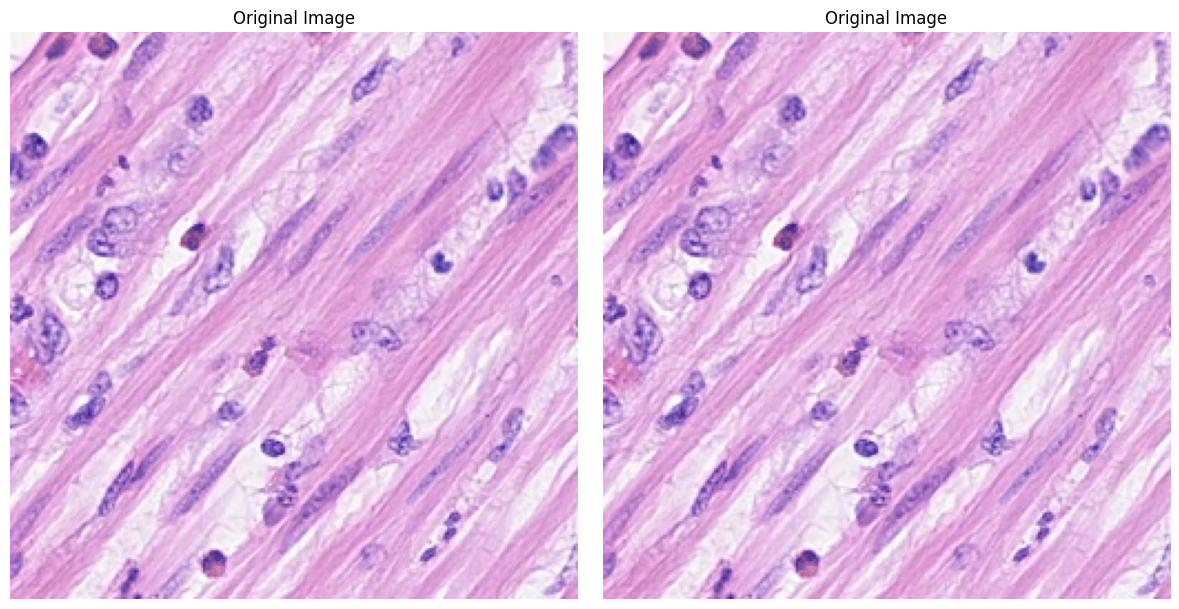

In [89]:
import matplotlib.pyplot as plt
from skimage.io import imread, imsave
from skimage import exposure
import random


path_train_images = Path('image_preprocessing/data/train')                                                              # important
subdirs = sorted([d.name for d in path_train_images.iterdir() if d.is_dir()])                                           # sorted image list in train

if not subdirs:
    raise FileNotFoundError('No Images found in \x1B[3mimage_preprocessing/data/train\x1B[0m')

rand_img = random.randint(0, len(subdirs)-1) if random_image == True else 0                                             # random_image = True can be changed at the top of the file

images_dir = path_train_images / subdirs[rand_img] / 'images'                                                           # kinda overkill but accepting multiple datatypes; also at the top
example_image_path = next(
    (f for f in images_dir.iterdir() if f.is_file() and f.suffix.lower() in image_datatypes),
    None
)







# why needed?           | 
# not working without   V







# use only RGB channels if available
image = imread(example_image_path)[:, :, :3]

intensity_range = np.max(image) - np.min(image)                                                                         # intensity_range = lightest_pixel - darkest_pixel

# Set a threshold for low contrast (e.g., range less than 50 for an 8-bit image)
low_contrast_threshold = 50                                                                                             # § hier

# Decide whether to apply CLAHE
if intensity_range < low_contrast_threshold:
    print('Low contrast detected, applying CLAHE.')
    # Normalize to [0, 1] for CLAHE
    image_normalized = image / 255.0

    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    enhanced_image = exposure.equalize_adapthist(image_normalized, clip_limit=0.03)  # Adjust clip_limit as needed

    # Convert back to [0, 255] range for visualization
    enhanced_image_uint8 = (enhanced_image * 255).astype('uint8')
else:
    print('Sufficient contrast, no CLAHE applied.')
    enhanced_image_uint8 = image

# Plot the original and enhanced images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(enhanced_image_uint8)
axes[1].set_title('Enhanced Image (CLAHE)' if intensity_range < low_contrast_threshold else 'Original Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [90]:
# for sample_dir in test_data.iterdir():
#     if not sample_dir.is_dir():
#         continue
#     if not sample_dir.name.startswith("img_"):
#         continue

#     # ID extrahieren, z. B. 0001
#     sample_id = sample_dir.name.replace("img_", "")
#     new_sample_name = f"img_noCLAHE_{sample_id}"
#     new_sample_dir = test_data / new_sample_name

#     # Zielordner für images & masks
#     new_img_dir = new_sample_dir / "images"
#     new_mask_dir = new_sample_dir / "masks"
#     new_img_dir.mkdir(parents=True, exist_ok=True)
#     new_mask_dir.mkdir(parents=True, exist_ok=True)

#     # Images kopieren
#     for img_file in (sample_dir / "images").glob("*.png"):
#         new_name = f"img_noCLAHE_{sample_id}.png"
#         shutil.copy(img_file, new_img_dir / new_name)

#     # Masks kopieren
#     for mask_file in (sample_dir / "masks").glob("*.png"):
#         new_name = f"img_noCLAHE_{sample_id}.png"
#         shutil.copy(mask_file, new_mask_dir / new_name)

# print("Fertig: Neue Ordner img_noCLAHE_xxxx wurden erstellt.")

### 2.3. Enhancing Images using CLAHE

In [91]:

preprocessed_train_images = Path('image_preprocessing') / 'preprocessed_data' / 'preprocessed_train_images'
preprocessed_train_masks  = Path('image_preprocessing') / 'preprocessed_data' / 'preprocessed_train_masks'

preprocessed_test_images  = Path('image_preprocessing') / 'preprocessed_data' / 'preprocessed_test_images'
preprocessed_test_masks   = Path('image_preprocessing') / 'preprocessed_data' / 'preprocessed_test_masks'


Path(preprocessed_train_images).mkdir(parents=True, exist_ok=True)
Path(preprocessed_train_masks).mkdir(parents=True, exist_ok=True)

Path(preprocessed_test_images).mkdir(parents=True, exist_ok=True)
Path(preprocessed_test_masks).mkdir(parents=True, exist_ok=True)


# Define image_ids by listing directories in the training dataset folder
image_ids = [i.name for i in Path(path_train_images).iterdir() if i.is_dir()]

for i_id in image_ids:
    tmp_dir = path_train_images / i_id / 'images'
    i_dir   = [f for f in tmp_dir.iterdir() if f.is_file() and f.suffix.lower() in image_datatypes][0]
    image   = imread(i_dir)[:, :, :3]

    if exposure.is_low_contrast(image, fraction_threshold=0.3):                                                         # $ hier!!!
        print(f'\x1B[3mEnhancing contrast for image {i_id} using CLAHE.\x1B[0m')
        image = exposure.equalize_adapthist(image / 255.0)
        image = (image * 255).astype(np.uint8)

    imsave((preprocessed_train_images / f'{i_id}_enhanced.png'), image)                                                 # from here on, .png is the best option to use




Enhancing contrast for image img_0026 using CLAHE.
Enhancing contrast for image img_0028 using CLAHE.
Enhancing contrast for image img_0032 using CLAHE.
Enhancing contrast for image img_0053 using CLAHE.
Enhancing contrast for image img_0069 using CLAHE.
Enhancing contrast for image img_0070 using CLAHE.
Enhancing contrast for image img_0072 using CLAHE.
Enhancing contrast for image img_0086 using CLAHE.
Enhancing contrast for image img_0103 using CLAHE.
Enhancing contrast for image img_0120 using CLAHE.
Enhancing contrast for image img_0124 using CLAHE.
Enhancing contrast for image img_0125 using CLAHE.
Enhancing contrast for image img_0126 using CLAHE.
Enhancing contrast for image img_0128 using CLAHE.
Enhancing contrast for image img_0131 using CLAHE.
Enhancing contrast for image img_0132 using CLAHE.
Enhancing contrast for image img_0214 using CLAHE.
Enhancing contrast for image img_0217 using CLAHE.
Enhancing contrast for image img_0225 using CLAHE.
Enhancing contrast for image im

### 2.4. Combining masks and resizing images (train images)

In [92]:
from skimage.color import rgb2gray
from skimage.transform import resize
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import torch




import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="skimage")





def  load_and_combine_masks(masks_dir, img_shape):
    """
    This function combines multiple masks into one big mask, if every cell has it's own mask-file

    :masks_dir:
    :img_shape:
    """
    combined_mask = np.zeros(img_shape[:2], dtype=np.uint8)
    masks = Path(masks_dir).iterdir()

    for m in masks:
        m_path = masks_dir / m
        mask   = imread(m_path)

        if mask.ndim == 3:
            print(f'Warning: RGB-mask detected in {m} - will be converted to Grayscale.')
            mask = rgb2gray(mask)
            mask = (mask > 0.5).astype(np.uint8)

        combined_mask = np.maximum(combined_mask, mask)

    return combined_mask


def resize_train_images_and_masks(i_id, base_path, preprocessed_train_images, preprocessed_train_masks, img_height=256, img_width=256):
    """
    

    :i_id:
    :base_path:
    :preprocessed_train_images:
    :img_height:
    :img_width:
    """
    image_dir = preprocessed_train_images / f'{i_id}_enhanced.png'                                                         # since we saved it previously as .png nothing fancy is needed here     (überprüfen § hier)
    mask_dir  = base_path / i_id / 'masks'
    
    image = imread(image_dir)[:, :, :3]
    mask  = load_and_combine_masks(mask_dir.resolve(), image.shape)
    
    image_resized = resize(image, (img_height, img_width), mode='constant', preserve_range=True)
    mask_resized  = resize(mask,  (img_height, img_width), mode='constant', preserve_range=True)

    image_resized = (image_resized / 255).astype(np.float32)
    mask_resized  = (mask_resized > 0).astype(np.uint8)

    # Check if the mask is empty (i.e., all pixel values are 0)                                                         # redundant as I've already done this check when copying from YOUR_data to the train|test folders in image_preprocessing/data
    if np.sum(mask_resized) == 0:
        print(f'Skipping Image {i_id} because the mask is empty.')
        return None, None  # Return None for both image and mask if mask is empty

    # print(f'Original Image  - dtype: {str(image.dtype):<7}  min: {round(float(image.min()), 4):<7}  max: {round(float(image.max()), 4):<7}  shape: {str(image.shape):<15}\n'
    #       f'Original Mask   - dtype: {str(mask.dtype):<7}  min: {round(float(mask.min()), 4):<7}  max: {round(float(mask.max()), 4):<7}  shape: {str(mask.shape):<15}\n'
    #       f'Resized Image   - dtype: {str(image_resized.dtype):<7}  min: {round(float(image_resized.min()), 4):<7}  max: {round(float(image_resized.max()), 4):<7}  shape: {str(image_resized.shape):<15}\n'
    #       f'Resized Mask    - dtype: {str(mask_resized.dtype):<7}  min: {round(float(mask_resized.min()), 4):<7}  max: {round(float(mask_resized.max()), 4):<7}  shape: {str(mask_resized.shape):<15}\n')
    
    imsave((preprocessed_train_images / f'{i_id}_pp_enhanced.png'), (image_resized * 255).astype(np.uint8))
    imsave((preprocessed_train_masks  / f'{i_id}_mask.png'),        (mask_resized  * 255).astype(np.uint8))

    return image_resized, mask_resized

# Preprocess all images and masks from the dataset and filter out empty masks                                           # redundant? because of ↑
X = []                                                                                                                  # images list
Y = []                                                                                                                  # masks list

for i_id in image_ids:
    # print(preprocessed_train_images)
    # print(preprocessed_train_masks)
    image_resized, mask_resized = resize_train_images_and_masks(i_id, train_data, preprocessed_train_images, preprocessed_train_masks)

    # Only append if both image and mask are not None (i.e., if the mask is not empty)
    if image_resized is not None and mask_resized is not None:
        X.append(image_resized)
        Y.append(mask_resized)

X = np.array(X)
Y = np.array(Y)

# Debugging: Check the shape of X and Y
print(f'Shape of X (Images): \t\t{str(X.shape):<30} │ Shape of Y (Masks): \t{str(Y.shape):<30}')



# Split data into training and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.1, random_state=42)

# Debugging: Check the shape of training and validation sets
print(f'Training set - X_train: \t{str(X_train.shape):<30} │ Y_train: \t\t{str(Y_train.shape):<30}')
print(f'Validation set - X_val: \t{str(X_val.shape):<30} │ Y_val: \t\t\t{str(Y_val.shape):<30}\n{"─"*63}┼{"─"*50}')

# Data transformation
train_transform = transforms.Compose([transforms.ToTensor()])
val_transform   = transforms.Compose([transforms.ToTensor()])




# Custom Dataset to load images and masks (train/validation)
class SegmentationDataset(Dataset):                                                                                     # § hier überarbeiten/überprüfen was das macht
    def __init__(self, images, masks, transform=None):
        self.images    = images
        self.masks     = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask  = self.masks[idx].astype(np.float32)  # Ensure mask is float32

        # Debugging: Print the shape of the image and mask before transform
        print(f'Original Image shape: \t\t{str(image.shape):<30} │ Mask shape: \t\t{str(mask.shape):<30}')

        if self.transform:
            image = self.transform(image)
            mask  = torch.tensor(mask, dtype=torch.float32)  # Ensure mask is float32 in PyTorch

            # Debugging: Print the shape after transformation to ensure it is still valid
            print(f'Transformed Image shape: \t{str(image.shape):<30} │ Transformed Mask shape: \t{str(mask.shape):<30}\n{"─"*63}┼{"─"*50}')

        return image, mask


# Create DataLoader for training and validation
train_dataset = SegmentationDataset(X_train, Y_train, transform=train_transform)
val_dataset   = SegmentationDataset(X_val, Y_val, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Check if DataLoader is working properly with correct types and range
def check_data_loader(train_loader):
    print()
    for batch_idx, (images, masks) in enumerate(train_loader):
        print(f'Batch {batch_idx + 1} - Image dtype: \t{images.dtype} \tMask dtype: \t{masks.dtype}')
        print(f'Batch {batch_idx + 1} - Image min: \t{round(float(images.min()), 4)} \tmax: \t{round(float(images.max()), 4)}')
        print(f'Batch {batch_idx + 1} - Mask min: \t{round(float(masks.min()), 4)} \tmax: \t{round(float(masks.max()), 4)}')
        break  # Only check the first batch




# Now the check_data_loader is defined, you can call it here
check_data_loader(train_loader)



Shape of X (Images): 		(500, 256, 256, 3)             │ Shape of Y (Masks): 	(500, 256, 256)               
Training set - X_train: 	(450, 256, 256, 3)             │ Y_train: 		(450, 256, 256)               
Validation set - X_val: 	(50, 256, 256, 3)              │ Y_val: 			(50, 256, 256)                
───────────────────────────────────────────────────────────────┼──────────────────────────────────────────────────

Original Image shape: 		(256, 256, 3)                  │ Mask shape: 		(256, 256)                    
Transformed Image shape: 	torch.Size([3, 256, 256])      │ Transformed Mask shape: 	torch.Size([256, 256])        
───────────────────────────────────────────────────────────────┼──────────────────────────────────────────────────
Original Image shape: 		(256, 256, 3)                  │ Mask shape: 		(256, 256)                    
Transformed Image shape: 	torch.Size([3, 256, 256])      │ Transformed Mask shape: 	torch.Size([256, 256])        
────────────────────────────

### 2.5. Combining masks and resizing images (test images)

In [93]:


def resize_test_imagess(i_id, base_path, img_height=256, img_width=256):
    """
    
    :i_id:
    :base_path:
    :img_height:
    :img_width:
    """
    
    tmp_dir = base_path / i_id / 'images'
    i_dir   = [f for f in tmp_dir.iterdir() if f.is_file() and f.suffix.lower() in image_datatypes][0]
    image   = imread(i_dir)[:, :, :3]

    if exposure.is_low_contrast(image, fraction_threshold=0.3):                                                         # $ hier!!!
        # if 'noCLAHE' not in i_id:
        #     print(f'\n \x1B[3mEnhancing contrast for image {i_id} using CLAHE.\x1B[0m\n')
        #     image = exposure.equalize_adapthist((image / 255.0), clip_limit=0.03)                                           # § hier mögliche parameteränderung
        #     image = (image * 255).astype(np.float32)

        print(f'\n \x1B[3mEnhancing contrast for image {i_id} using CLAHE.\x1B[0m\n')
        image = exposure.equalize_adapthist((image / 255.0), clip_limit=0.03)                                           # § hier mögliche parameteränderung
        image = (image * 255).astype(np.float32)



        

    image_resized = resize(image, (img_height, img_width), mode='constant', preserve_range=True).astype(np.float32)
    image_resized = (image_resized / 255.0).astype(np.float32)

    imsave((preprocessed_test_images / f'{i_id}.png'), (image_resized * 255).astype(np.uint8))
    
    print(f'Original Testimage shape: \t{image.shape}, dtype: {image.dtype}\n'
          f'Resized Testimage shape:  \t{image_resized.shape}, dtype: {image_resized.dtype}')

    return image_resized

X_test = []

image_ids_test = [i.name for i in Path(test_data).iterdir() if i.is_dir()]

for i_id in image_ids_test:
    image_resized = resize_test_imagess(i_id, test_data)
    X_test.append(image_resized)

X_test = np.array(X_test)


class TestDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]

        # Debugging: Print the shape of the image before transform
        print(f'Original Testimage shape: \t{str(image.shape):<30} dtype: {image.dtype}')

        if self.transform:
            image = self.transform(image)

            # Debugging: Print the shape and type after transformation
            print(f'Transformed Testimage shape: \t{str(image.shape):<30} dtype: {image.dtype}\n{"─"*85}')

        return image
    

test_transform = transforms.Compose([
    transforms.ToTensor(),  # Converts numpy array to tensor
    transforms.ConvertImageDtype(torch.float32)  # Ensures the image is in float32
])

# DataLoader for test data
test_dataset = TestDataset(X_test, transform=test_transform)  # Use test_transform here
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Debugging: Check the shape of a batch from the test DataLoader
for images in test_loader:
    print(f'Batch Shape - Test Images: \t{str(image.shape):<30} dtype: {images.dtype}')
    break  # Just check the first batch for debugging purposes



Original Testimage shape: 	(256, 256, 3), dtype: uint8
Resized Testimage shape:  	(256, 256, 3), dtype: float32

 Enhancing contrast for image img_0080 using CLAHE.

Original Testimage shape: 	(256, 256, 3), dtype: float32
Resized Testimage shape:  	(256, 256, 3), dtype: float32

 Enhancing contrast for image img_0211 using CLAHE.

Original Testimage shape: 	(256, 256, 3), dtype: float32
Resized Testimage shape:  	(256, 256, 3), dtype: float32

 Enhancing contrast for image img_0236 using CLAHE.

Original Testimage shape: 	(256, 256, 3), dtype: float32
Resized Testimage shape:  	(256, 256, 3), dtype: float32
Original Testimage shape: 	(256, 256, 3), dtype: uint8
Resized Testimage shape:  	(256, 256, 3), dtype: float32

 Enhancing contrast for image img_0343 using CLAHE.

Original Testimage shape: 	(256, 256, 3), dtype: float32
Resized Testimage shape:  	(256, 256, 3), dtype: float32
Original Testimage shape: 	(256, 256, 3), dtype: uint8
Resized Testimage shape:  	(256, 256, 3), dtype: 

### 2.6. HIER, was macht das und wie kann ich das in meinen Teil integrieren???

In [94]:
from skimage.io import imread

# Function to load saved ground truth masks from drive
'''
def load_saved_ground_truth_masks(test_image_ids, mask_dir):
    ground_truth_masks = {}
    for image_id in test_image_ids:
        mask_path = os.path.join(mask_dir, f"{image_id}_mask.png")
        if os.path.exists(mask_path):
            mask = imread(mask_path)
            ground_truth_masks[image_id] = mask
        else:
            print(f"Mask for {image_id} not found at {mask_path}")
    return ground_truth_masks

# Load saved ground truth masks
ground_truth_masks_loaded = load_saved_ground_truth_masks(test_image_ids, ground_truth_test_mask_dir)                   # hier

'''

'\ndef load_saved_ground_truth_masks(test_image_ids, mask_dir):\n    ground_truth_masks = {}\n    for image_id in test_image_ids:\n        mask_path = os.path.join(mask_dir, f"{image_id}_mask.png")\n        if os.path.exists(mask_path):\n            mask = imread(mask_path)\n            ground_truth_masks[image_id] = mask\n        else:\n            print(f"Mask for {image_id} not found at {mask_path}")\n    return ground_truth_masks\n\n# Load saved ground truth masks\nground_truth_masks_loaded = load_saved_ground_truth_masks(test_image_ids, ground_truth_test_mask_dir)                   # hier\n\n'

### 2.7 What is this? Always saying mask or image missing?

In [95]:
def load_train_images_and_masks(image_dir, mask_dir, image_size=(256, 256)):
    image_ids_ = [f.stem.split('_')[0] for f in Path(image_dir).iterdir() if f.suffix.lower() in image_datatypes]       # hier warum aufsplitten? Was soll das bringen? gerade da alle gleiche Namen haben?

    print(image_ids_)

    return None, None
    return images, masks


train_images, train_masks = load_train_images_and_masks(preprocessed_train_images, preprocessed_train_masks)

['img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img', 'img'

### 2.8 Keep and delete

In [96]:
for file in preprocessed_train_images.iterdir():

    if not file.name.endswith('_pp_enhanced.png'):
        try:
            # Delete the file
            file.unlink()
            print(f'Deleted: \t{file}')
        except Exception as e:
            print(f'Error deleting {file}: {e}')
    else:
        print(f'Kept: \t\t{file}')

Deleted: 	image_preprocessing\preprocessed_data\preprocessed_train_images\img_0026_enhanced.png
Kept: 		image_preprocessing\preprocessed_data\preprocessed_train_images\img_0026_pp_enhanced.png
Deleted: 	image_preprocessing\preprocessed_data\preprocessed_train_images\img_0028_enhanced.png
Kept: 		image_preprocessing\preprocessed_data\preprocessed_train_images\img_0028_pp_enhanced.png
Deleted: 	image_preprocessing\preprocessed_data\preprocessed_train_images\img_0032_enhanced.png
Kept: 		image_preprocessing\preprocessed_data\preprocessed_train_images\img_0032_pp_enhanced.png
Deleted: 	image_preprocessing\preprocessed_data\preprocessed_train_images\img_0051_enhanced.png
Kept: 		image_preprocessing\preprocessed_data\preprocessed_train_images\img_0051_pp_enhanced.png
Deleted: 	image_preprocessing\preprocessed_data\preprocessed_train_images\img_0053_enhanced.png
Kept: 		image_preprocessing\preprocessed_data\preprocessed_train_images\img_0053_pp_enhanced.png
Deleted: 	image_preprocessing\prepr

### 2.9. Test masks are just copied?

In [97]:
test_masks = [p for p in test_data.glob("*/masks/*") if p.suffix.lower() in image_datatypes]

test_masks = list(test_masks)
print(f'Gefundene Masken: {len(test_masks)}\n')

for mask in test_masks:
    target_path = preprocessed_test_masks / mask.name
    shutil.copy2(mask, target_path)
    print(f'Copied: \t{mask.name}')

Gefundene Masken: 100

Copied: 	img_0018.png
Copied: 	img_0080.png
Copied: 	img_0211.png
Copied: 	img_0236.png
Copied: 	img_0245.png
Copied: 	img_0343.png
Copied: 	img_0362.png
Copied: 	img_0376.png
Copied: 	img_0379.png
Copied: 	img_0497.png
Copied: 	img_0527.png
Copied: 	img_0557.png
Copied: 	img_0562.png
Copied: 	img_0565.png
Copied: 	img_0595.png
Copied: 	img_0793.png
Copied: 	img_0865.png
Copied: 	img_0899.png
Copied: 	img_0992.png
Copied: 	img_1021.png
Copied: 	img_1045.png
Copied: 	img_1086.png
Copied: 	img_1223.png
Copied: 	img_1243.png
Copied: 	img_1253.png
Copied: 	img_1293.png
Copied: 	img_1311.png
Copied: 	img_1443.png
Copied: 	img_1464.png
Copied: 	img_1490.png
Copied: 	img_1570.png
Copied: 	img_1625.png
Copied: 	img_1648.png
Copied: 	img_1668.png
Copied: 	img_1695.png
Copied: 	img_1734.png
Copied: 	img_1773.png
Copied: 	img_1792.png
Copied: 	img_1798.png
Copied: 	img_1827.png
Copied: 	img_1908.png
Copied: 	img_1940.png
Copied: 	img_1960.png
Copied: 	img_1994.png
Copied: 	

### 2.10. Number of Images and Masks that will be used for training and testing

In [98]:
def count_images_in_directory(directory):
    count = 0
    for file in directory.iterdir():
        if file.name.endswith('.png'):  # Adjust the extension if needed (e.g., .jpg)                                   # redundant I think as we only save .png files
            count += 1
    return count

# Count the images in each directory
train_image_count = count_images_in_directory(preprocessed_train_images)
test_image_count  = count_images_in_directory(preprocessed_test_images)
train_mask_count  = count_images_in_directory(preprocessed_train_masks)
test_mask_count   = count_images_in_directory(preprocessed_test_masks)

# Print the results
print(f"Number of images in {preprocessed_train_images}: {train_image_count}")
print(f"Number of images in {preprocessed_test_images}: {test_image_count}")
print(f"Number of masks in {preprocessed_train_masks}: {train_mask_count}")
print(f"Number of masks in {preprocessed_test_masks}: {test_mask_count}")

Number of images in image_preprocessing\preprocessed_data\preprocessed_train_images: 500
Number of images in image_preprocessing\preprocessed_data\preprocessed_test_images: 100
Number of masks in image_preprocessing\preprocessed_data\preprocessed_train_masks: 500
Number of masks in image_preprocessing\preprocessed_data\preprocessed_test_masks: 100


# TODO
## 1. Loss plotten
in DSB18_CellSeg....real_Version
learning rate lr=1e-4 anpassen
## 2. Training anpassen
training anhalten können

## 3. Unterschiede von CellSeg und CoNIC
+ Architektur von unet verstehen 
+ altes modell kann nicht mit neuen Daten laufe


#### 1.
AdamW mit weight decay
#### 2. Adam Hyper-Param ändern
lr=1e-4 learning rate / diceloss
#### 2. Bootstraping und/oder Jackknife